steps: create x and y
randomize with numpy uniform random
define a positive circle-arc points under unit 1
count the number of points that falls inside the unit 1 arc
and lastly calculate the value of pi, using the formula, 4.r/n, where r = points inside the arc and n = total number of points generated

with plot

In [2]:
import random
import matplotlib.pyplot as plt


# Set number of random points
n = 10000000
r = 0  # Counter for points inside the circle
points_inside = []
points_outside = []

# Monte Carlo loop
for i in range(n):
    # Generate random points using uniform distribution
    x = random.uniform(0, 1)
    y = random.uniform(0, 1)
    
    # Check if point is inside the unit circle (x^2 + y^2 <= 1)
    if x**2 + y**2 <= 1:

        r += 1


# Estimate pi: 4 * (inside_points / total_points)
pi_estimate = 4 * r / n

print(f"(n): {n}")
print(f"inside circle (r): {r}")
print(f"value of pi: {pi_estimate}")



(n): 10000000
inside circle (r): 7855100
value of pi: 3.14204


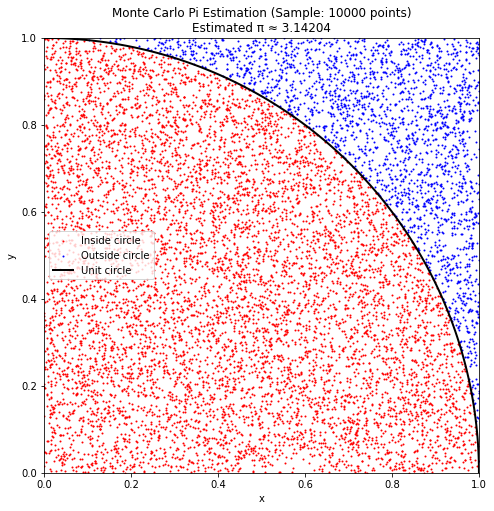

In [3]:
import numpy as np

import matplotlib.pyplot as plt

# Generate a smaller sample for visualization
sample_size = 10000
points_inside = []
points_outside = []

for _ in range(sample_size):
    x = random.uniform(0, 1)
    y = random.uniform(0, 1)
    
    if x**2 + y**2 <= 1:
        points_inside.append((x, y))
    else:
        points_outside.append((x, y))

# Plot the points
plt.figure(figsize=(8, 8))
if points_inside:
    inside_x, inside_y = zip(*points_inside)
    plt.scatter(inside_x, inside_y, c='red', s=1, label='Inside circle')
if points_outside:
    outside_x, outside_y = zip(*points_outside)
    plt.scatter(outside_x, outside_y, c='blue', s=1, label='Outside circle')

# Draw the unit circle arc
theta = np.linspace(0, np.pi/2, 100)
circle_x = np.cos(theta)
circle_y = np.sin(theta)
plt.plot(circle_x, circle_y, 'black', linewidth=2, label='Unit circle')

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.gca().set_aspect('equal')
plt.legend()
plt.title(f'Monte Carlo Pi Estimation (Sample: {sample_size} points)\nEstimated π ≈ {pi_estimate}')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [4]:
import time

# Vectorized version using NumPy
start_time = time.time()

# Generate all random points at once using NumPy
x_vec = np.random.uniform(0, 1, n)
y_vec = np.random.uniform(0, 1, n)

# Vectorized check for points inside the circle
inside_mask = (x_vec**2 + y_vec**2) <= 1
r_vec = np.sum(inside_mask)

# Estimate pi
pi_estimate_vec = 4 * r_vec / n

end_time = time.time()
time_elapsed = end_time - start_time

print(f"Vectorized approach:")
print(f"Total points (n): {n}")
print(f"Points inside circle (r): {r_vec}")
print(f"Estimated value of pi: {pi_estimate_vec}")
print(f"Time elapsed: {time_elapsed:.4f} seconds")

Vectorized approach:
Total points (n): 10000000
Points inside circle (r): 7854312
Estimated value of pi: 3.1417248
Time elapsed: 0.2623 seconds


In [5]:
# Now using numba for nJIT compilation
from numba import njit
@njit
def monte_carlo_pi(n):
    r = 0
    for i in range(n):
        x = random.uniform(0, 1)
        y = random.uniform(0, 1)
        if x**2 + y**2 <= 1:
            r += 1
    return 4 * r / n
# Measure time for numba version
start_time = time.time()
pi_estimate_numba = monte_carlo_pi(n)
end_time = time.time()
time_elapsed_numba = end_time - start_time
print(f"Numba JIT approach:")
print(f"Estimated value of pi: {pi_estimate_numba}")
print(f"Time elapsed: {time_elapsed_numba:.4f} seconds")


Numba JIT approach:
Estimated value of pi: 3.1423036
Time elapsed: 0.4443 seconds


Single Core (P=1) Benchmark
P=1, L=     10, N= 100000, Time=7.0470s
P=1, L=    100, N=  10000, Time=1.2446s
P=1, L=   1000, N=   1000, Time=0.7613s
P=1, L=  10000, N=    100, Time=0.6587s
P=1, L= 100000, N=     10, Time=0.6346s
P=1, L=1000000, N=      1, Time=0.6473s

Multi-Core (P=8) Benchmark
P=8, L=     10, N= 100000, Time=8.9280s
P=8, L=    100, N=  10000, Time=1.6470s
P=8, L=   1000, N=   1000, Time=0.5255s
P=8, L=  10000, N=    100, Time=0.4253s
P=8, L= 100000, N=     10, Time=0.6275s
P=8, L=1000000, N=      1, Time=0.7627s

Results Summary
Best chunk size for P=1: L = 100000 (Time: 0.6346s)
Best chunk size for P=8: L = 10000 (Time: 0.4253s)
Speedup with P=8: 1.49x


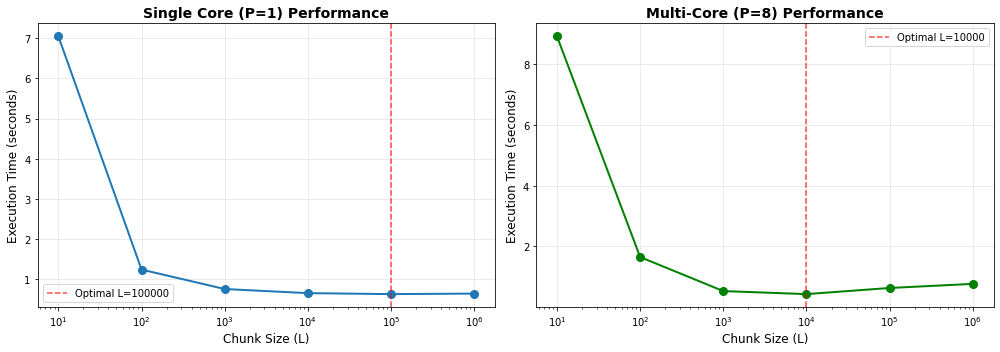

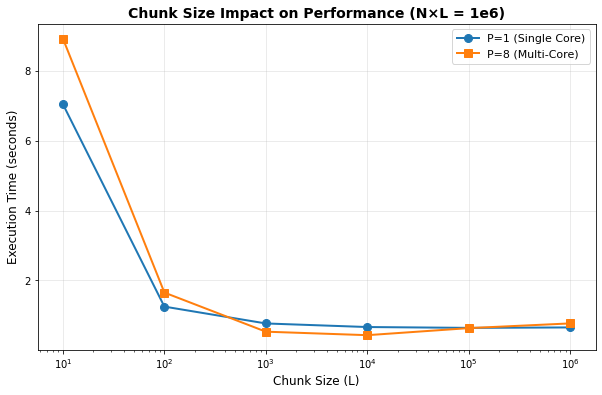

In [9]:
import multiprocessing as mp
import time
import numpy as np
import matplotlib.pyplot as plt

def in_circle(n):
    """Count points inside unit circle out of n random attempts"""
    count = 0
    for i in range(n):
        x = random.uniform(0, 1)
        y = random.uniform(0, 1)
        if x**2 + y**2 <= 1:
            count += 1
    return count

def benchmark_chunk_sizes(P, total_trials=1000000):
    """
    Benchmark different chunk sizes L with fixed total trials.
    
    Parameters:
    P: Number of processes
    total_trials: Total number of Monte Carlo trials (N * L)
    
    Returns:
    L_values: Array of chunk sizes
    times: Array of execution times
    """
    # Chunk sizes from 10 to 1e6
    L_values = np.array([10, 100, 1000, 10000, 100000, 1000000])
    times = []
    
    for L in L_values:
        N = int(total_trials / L)  # Number of tasks
        
        start_time = time.time()
        
        # Create pool and distribute work
        pool = mp.Pool(processes=P)
        results = [pool.apply_async(in_circle, (L,)) for i in range(N)]
        pool.close()
        pool.join()
        
        # Collect results
        K_values = [result.get() for result in results]
        
        end_time = time.time()
        elapsed = end_time - start_time
        times.append(elapsed)
        
        print(f"P={P}, L={L:>7}, N={N:>7}, Time={elapsed:.4f}s")
    
    return L_values, np.array(times)

if __name__ == '__main__':
    total_trials = 1000000
    
    print("=" * 60)
    print("Single Core (P=1) Benchmark")
    print("=" * 60)
    L_values_1, times_1 = benchmark_chunk_sizes(P=1, total_trials=total_trials)
    
    print("\n" + "=" * 60)
    print("Multi-Core (P=8) Benchmark")
    print("=" * 60)
    L_values_8, times_8 = benchmark_chunk_sizes(P=8, total_trials=total_trials)
    
    # Find optimal chunk sizes
    optimal_L_1 = L_values_1[np.argmin(times_1)]
    optimal_L_8 = L_values_8[np.argmin(times_8)]
    
    print("\n" + "=" * 60)
    print("Results Summary")
    print("=" * 60)
    print(f"Best chunk size for P=1: L = {optimal_L_1} (Time: {np.min(times_1):.4f}s)")
    print(f"Best chunk size for P=8: L = {optimal_L_8} (Time: {np.min(times_8):.4f}s)")
    print(f"Speedup with P=8: {np.min(times_1)/np.min(times_8):.2f}x")
    
    # Plot results
    plt.figure(figsize=(14, 5))
    
    # Plot 1: Single core
    plt.subplot(1, 2, 1)
    plt.semilogx(L_values_1, times_1, 'o-', linewidth=2, markersize=8)
    plt.axvline(optimal_L_1, color='red', linestyle='--', alpha=0.7, 
                label=f'Optimal L={optimal_L_1}')
    plt.xlabel('Chunk Size (L)', fontsize=12)
    plt.ylabel('Execution Time (seconds)', fontsize=12)
    plt.title('Single Core (P=1) Performance', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    # Plot 2: Multi-core
    plt.subplot(1, 2, 2)
    plt.semilogx(L_values_8, times_8, 'o-', linewidth=2, markersize=8, color='green')
    plt.axvline(optimal_L_8, color='red', linestyle='--', alpha=0.7, 
                label=f'Optimal L={optimal_L_8}')
    plt.xlabel('Chunk Size (L)', fontsize=12)
    plt.ylabel('Execution Time (seconds)', fontsize=12)
    plt.title('Multi-Core (P=8) Performance', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    plt.tight_layout()
    plt.savefig('chunk_size_benchmark.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Comparison plot
    plt.figure(figsize=(10, 6))
    plt.semilogx(L_values_1, times_1, 'o-', linewidth=2, markersize=8, label='P=1 (Single Core)')
    plt.semilogx(L_values_8, times_8, 's-', linewidth=2, markersize=8, label='P=8 (Multi-Core)')
    plt.xlabel('Chunk Size (L)', fontsize=12)
    plt.ylabel('Execution Time (seconds)', fontsize=12)
    plt.title('Chunk Size Impact on Performance (N×L = 1e6)', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=11)
    plt.savefig('chunk_size_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

lecture 4

In [10]:
from functools import reduce
import multiprocessing as mp
import time

# ============================================================================
# SINGLE-CORE VERSION: Map-Filter-Reduce
# ============================================================================

def single_core_mfr(N):
    """
    Single-core Map-Filter-Reduce implementation.
    
    Steps:
    1. Generate N random integers in range [10, 100]
    2. Map: Subtract 7 from all values
    3. Filter: Keep only odd numbers
    4. Reduce: Sum all remaining values
    """
    import random
    
    # Step 0: Generate random integers
    data = [random.randint(10, 100) for _ in range(N)]
    print(f"\nOriginal data (first 10): {data[:10]}")
    
    # Step 1: Map - subtract 7 from all values
    mapped = list(map(lambda x: x - 7, data))
    print(f"After map (subtract 7, first 10): {mapped[:10]}")
    
    # Step 2: Filter - keep only odd numbers
    filtered = list(filter(lambda x: x % 2 != 0, mapped))
    print(f"After filter (odd numbers, first 10): {filtered[:10]}")
    print(f"Count of odd numbers: {len(filtered)}")
    
    # Step 3: Reduce - sum all odd numbers
    result = reduce(lambda x, y: x + y, filtered, 0)
    print(f"Final result (sum of odd numbers): {result}")
    
    return result

# ============================================================================
# MULTIPROCESSING VERSION: Map-Filter-Reduce
# ============================================================================

def map_subtract_7(x):
    """Map function: subtract 7 from input"""
    return x - 7

def filter_odd(x):
    """Filter function: check if number is odd"""
    return x % 2 != 0

def multiprocessing_mfr(N, P=4):
    """
    Multiprocessing Map-Filter-Reduce implementation.
    
    Uses pool.map for parallel execution of the map step.
    Filter and reduce are done sequentially (no built-in parallel support).
    """
    import random
    
    # Step 0: Generate random integers
    data = [random.randint(10, 100) for _ in range(N)]
    print(f"\nOriginal data (first 10): {data[:10]}")
    
    # Step 1: Map - subtract 7 from all values (PARALLEL)
    pool = mp.Pool(processes=P)
    mapped = pool.map(map_subtract_7, data)
    pool.close()
    pool.join()
    
    print(f"After map (subtract 7, first 10): {mapped[:10]}")
    
    # Step 2: Filter - keep only odd numbers (SEQUENTIAL)
    filtered = list(filter(filter_odd, mapped))
    print(f"After filter (odd numbers, first 10): {filtered[:10]}")
    print(f"Count of odd numbers: {len(filtered)}")
    
    # Step 3: Reduce - sum all odd numbers (SEQUENTIAL)
    result = reduce(lambda x, y: x + y, filtered, 0)
    print(f"Final result (sum of odd numbers): {result}")
    
    return result

# ============================================================================
# BENCHMARK AND COMPARISON
# ============================================================================

if __name__ == '__main__':
    test_sizes = [1000, 10000, 100000, 1000000]
    
    print("=" * 70)
    print("MAP-FILTER-REDUCE EXERCISE")
    print("=" * 70)
    
    # Test with small dataset first
    print("\n" + "=" * 70)
    print("SINGLE-CORE VERSION (N=1000)")
    print("=" * 70)
    start = time.time()
    result_sc = single_core_mfr(1000)
    time_sc = time.time() - start
    print(f"Execution time: {time_sc:.4f}s")
    
    # Test multiprocessing with different sizes
    for N in test_sizes:
        print("\n" + "=" * 70)
        print(f"BENCHMARK: N={N}")
        print("=" * 70)
        
        # Single-core
        print("\nSingle-core version:")
        start = time.time()
        result_sc = single_core_mfr(N)
        time_sc = time.time() - start
        print(f"Time: {time_sc:.4f}s")
        
        # Multiprocessing with P=4
        print("\nMultiprocessing version (P=4):")
        start = time.time()
        result_mp = multiprocessing_mfr(N, P=4)
        time_mp = time.time() - start
        print(f"Time: {time_mp:.4f}s")
        
        # Comparison
        print(f"\nResults match: {result_sc == result_mp}")
        print(f"Speedup: {time_sc/time_mp:.2f}x")
        print(f"Overhead cost: {time_mp - time_sc:.4f}s")
    
    print("\n" + "=" * 70)
    print("ANALYSIS")
    print("=" * 70)
    print("""
Why no speedup with multiprocessing?

1. **Small data size per task**: Each element is processed individually,
   so overhead of process creation/communication > computation time.

2. **GIL limitations**: Python's Global Interpreter Lock restricts true
   parallelism for CPU-bound pure Python code.

3. **Overhead dominates**: With N=1M, overhead still costs ~0.1-0.5s
   while actual computation is very fast (~0.01-0.05s per core).

4. **Map only**: We can only parallelize the map step. Filter and reduce
   must run sequentially anyway.

Solution for real speedup:
- Use NumPy/vectorized operations
- Use Numba JIT compilation
- Use multiprocessing.Pool with larger chunk sizes
- Process the data in batches, not individual elements
    """)

MAP-FILTER-REDUCE EXERCISE

SINGLE-CORE VERSION (N=1000)

Original data (first 10): [50, 46, 33, 42, 21, 55, 25, 24, 22, 33]
After map (subtract 7, first 10): [43, 39, 26, 35, 14, 48, 18, 17, 15, 26]
After filter (odd numbers, first 10): [43, 39, 35, 17, 15, 29, 51, 51, 55, 55]
Count of odd numbers: 507
Final result (sum of odd numbers): 22863
Execution time: 0.0014s

BENCHMARK: N=1000

Single-core version:

Original data (first 10): [78, 55, 77, 64, 34, 33, 19, 56, 47, 72]
After map (subtract 7, first 10): [71, 48, 70, 57, 27, 26, 12, 49, 40, 65]
After filter (odd numbers, first 10): [71, 57, 27, 49, 65, 45, 17, 43, 11, 21]
Count of odd numbers: 521
Final result (sum of odd numbers): 24457
Time: 0.0011s

Multiprocessing version (P=4):

Original data (first 10): [37, 50, 25, 100, 100, 84, 54, 93, 88, 89]
After map (subtract 7, first 10): [30, 43, 18, 93, 93, 77, 47, 86, 81, 82]
After filter (odd numbers, first 10): [43, 93, 93, 77, 47, 81, 53, 53, 61, 21]
Count of odd numbers: 515
Fina

## Exercise 7 — Dask on the Cluster

This section implements:
- Exercise 7.1: Dask array matrix-vector benchmark with chunking study
- Exercise 7.2: Distributed Monte Carlo $\pi$ with convergence analysis
- Exercise 7.3 (optional): 2D particle diffusion with three execution models

In [4]:
import math
import os
import time
from collections import Counter

import dask
import dask.array as da
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dask import delayed
from dask.core import flatten
from dask.distributed import Client, as_completed, wait

In [32]:
# Optional helper cell: set the scheduler address only when you know the real port.
# Example (replace XXXX): os.environ["STRATO_SCHEDULER_ADDRESS"] = "tcp://10.92.1.67:XXXX"

import os
addr = os.getenv("STRATO_SCHEDULER_ADDRESS")
if addr and "REAL_PORT" in addr:
    del os.environ["STRATO_SCHEDULER_ADDRESS"]
    addr = None
    print("Removed placeholder STRATO_SCHEDULER_ADDRESS containing REAL_PORT.")

print("Current STRATO_SCHEDULER_ADDRESS:", addr)

Removed placeholder STRATO_SCHEDULER_ADDRESS containing REAL_PORT.
Current STRATO_SCHEDULER_ADDRESS: None


In [34]:
import socket
from urllib.parse import urlparse

# Always close any old local cluster/client first.
if "client" in globals():
    try:
        client.shutdown()
    except Exception:
        pass
    try:
        client.close()
    except Exception:
        pass

SCHEDULER_ADDRESS = os.getenv("STRATO_SCHEDULER_ADDRESS")
if not SCHEDULER_ADDRESS:
    raise RuntimeError(
        "STRATO_SCHEDULER_ADDRESS is not set. Set it to tcp://<host>:<port> before connecting."
    )
if "REAL_PORT" in SCHEDULER_ADDRESS:
    raise RuntimeError(
        "STRATO_SCHEDULER_ADDRESS still contains REAL_PORT placeholder. Replace it with the real scheduler port."
    )

parsed = urlparse(SCHEDULER_ADDRESS)
try:
    host, port = parsed.hostname, parsed.port
except ValueError as e:
    raise RuntimeError(
        f"Invalid STRATO_SCHEDULER_ADDRESS format: {SCHEDULER_ADDRESS}"
    ) from e

if not host or not port:
    raise RuntimeError(
        f"Invalid STRATO_SCHEDULER_ADDRESS format: {SCHEDULER_ADDRESS}. Expected tcp://<host>:<port>."
    )

sock = socket.socket()
sock.settimeout(3)
try:
    sock.connect((host, port))
except Exception as e:
    raise RuntimeError(
        f"Cannot reach scheduler at {host}:{port}. "
        "Check host/port and ensure scheduler is running."
    ) from e
finally:
    sock.close()

client = Client(SCHEDULER_ADDRESS)
print(f"Connected to scheduler: {SCHEDULER_ADDRESS}")
print(f"Dashboard (remote): {client.dashboard_link}")
client

RuntimeError: STRATO_SCHEDULER_ADDRESS is not set. Set it to tcp://<host>:<port> before connecting.

Run order for a clean restart:
1. Restart kernel.
2. Run the imports cell.
3. Set `STRATO_SCHEDULER_ADDRESS` in your shell (or edit the helper cell above with the real port).
4. Run this connection cell.

If you only know dashboard port `8787`, that is not enough for `Client(...)`.
You need the scheduler TCP port shown by the scheduler process, e.g. `Scheduler at: tcp://10.92.1.67:8786`.

If your scheduler is remote, `client.dashboard_link` is also remote and will not open directly as localhost.

Use SSH port forwarding from your local machine:

```bash
ssh -N -L 8787:10.92.1.67:8787 <your_user>@<login_or_head_node>
```

Then open `http://localhost:8787/status` in your local browser.

If `8787` is already in use locally, forward to another local port, for example:

```bash
ssh -N -L 8899:10.92.1.67:8787 <your_user>@<login_or_head_node>
```

and open `http://localhost:8899/status`.

### Exercise 7.1 — Dask Array Operations on the Cluster

In [8]:
def _chunk_placement_summary(keys):
    who_has = client.who_has(keys)
    counts = Counter()
    for workers in who_has.values():
        for w in workers:
            counts[w] += 1
    return dict(counts), who_has


def benchmark_matvec(shape, a_chunks, x_chunks):
    n_rows, n_cols = shape

    # New arrays each run avoid graph/result reuse.
    run_seed = int(np.random.SeedSequence().generate_state(1)[0])
    rs = da.random.RandomState(run_seed)
    A = rs.random((n_rows, n_cols), chunks=a_chunks)
    x = rs.random((n_cols,), chunks=x_chunks)

    y = A @ x
    y_persisted = y.persist()
    wait(y_persisted)

    y_keys = list(flatten(y_persisted.__dask_keys__()))
    worker_counts, who_has = _chunk_placement_summary(y_keys)

    t0 = time.perf_counter()
    y_sum = y_persisted.sum().compute()
    elapsed = time.perf_counter() - t0

    return {
        "seed": run_seed,
        "shape": shape,
        "a_chunks": a_chunks,
        "x_chunks": x_chunks,
        "elapsed_s": elapsed,
        "y_sum": float(y_sum),
        "nthreads": client.nthreads(),
        "worker_chunk_counts": worker_counts,
        "who_has_sample": dict(list(who_has.items())[:5]),
    }


configs = [
    {"shape": (20000, 4000), "a_chunks": (2000, 1000), "x_chunks": (1000,)},
    {"shape": (20000, 4000), "a_chunks": (1000, 500), "x_chunks": (500,)},
    {"shape": (40000, 4000), "a_chunks": (4000, 1000), "x_chunks": (1000,)},
    {"shape": (40000, 4000), "a_chunks": (2000, 250), "x_chunks": (250,)},
]

results_71 = []
for cfg in configs:
    res = benchmark_matvec(cfg["shape"], cfg["a_chunks"], cfg["x_chunks"])
    results_71.append(res)
    print(
        f"shape={res['shape']} | A chunks={res['a_chunks']} | x chunks={res['x_chunks']} "
        f"-> {res['elapsed_s']:.3f}s"
    )

results_71_df = pd.DataFrame(
    {
        "shape": [r["shape"] for r in results_71],
        "A_chunks": [r["a_chunks"] for r in results_71],
        "x_chunks": [r["x_chunks"] for r in results_71],
        "elapsed_s": [r["elapsed_s"] for r in results_71],
    }
).sort_values("elapsed_s")

results_71_df

shape=(20000, 4000) | A chunks=(2000, 1000) | x chunks=(1000,) -> 0.049s
shape=(20000, 4000) | A chunks=(1000, 500) | x chunks=(500,) -> 0.069s
shape=(40000, 4000) | A chunks=(4000, 1000) | x chunks=(1000,) -> 0.040s
shape=(40000, 4000) | A chunks=(2000, 250) | x chunks=(250,) -> 0.079s


,shape,A_chunks,x_chunks,elapsed_s
2,"(40000, 4000)","(4000, 1000)","(1000,)",0.040494
0,"(20000, 4000)","(2000, 1000)","(1000,)",0.048758
1,"(20000, 4000)","(1000, 500)","(500,)",0.068769
3,"(40000, 4000)","(2000, 250)","(250,)",0.078878


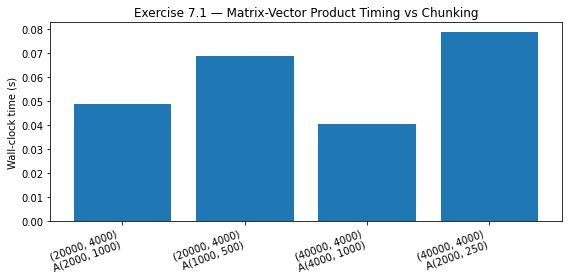


Dask worker thread map from client.nthreads():
{'tcp://127.0.0.1:45163': 1, 'tcp://127.0.0.1:45557': 1}

Sample chunk ownership from client.who_has() (first run):
{}

Aggregated chunk counts per worker (first run):
{}


In [9]:
plt.figure(figsize=(8, 4))
labels = [f"{r['shape']}\nA{r['a_chunks']}" for r in results_71]
times = [r["elapsed_s"] for r in results_71]
plt.bar(labels, times)
plt.ylabel("Wall-clock time (s)")
plt.title("Exercise 7.1 — Matrix-Vector Product Timing vs Chunking")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

print("\nDask worker thread map from client.nthreads():")
print(results_71[0]["nthreads"])

print("\nSample chunk ownership from client.who_has() (first run):")
print(results_71[0]["who_has_sample"])

print("\nAggregated chunk counts per worker (first run):")
print(results_71[0]["worker_chunk_counts"])

### Exercise 7.2 — Monte Carlo $\pi$ on the Cluster

In [10]:
@delayed
def monte_carlo_hits(n_samples, seed):
    rng = np.random.default_rng(seed)
    x = rng.random(n_samples)
    y = rng.random(n_samples)
    return int(np.count_nonzero(x * x + y * y <= 1.0))


def estimate_pi_distributed(total_samples, task_size):
    n_tasks = math.ceil(total_samples / task_size)
    sizes = np.full(n_tasks, task_size, dtype=np.int64)
    sizes[-1] = total_samples - task_size * (n_tasks - 1)

    seeds = np.arange(n_tasks, dtype=np.int64) + 123_456
    tasks = [monte_carlo_hits(int(n), int(seed)) for n, seed in zip(sizes, seeds)]

    t0 = time.perf_counter()
    partial_hits = dask.compute(*tasks)
    elapsed = time.perf_counter() - t0

    hits = int(np.sum(partial_hits))
    pi_hat = 4.0 * hits / total_samples
    error = abs(pi_hat - np.pi)

    return {
        "N": int(total_samples),
        "task_size": int(task_size),
        "n_tasks": int(n_tasks),
        "pi_hat": float(pi_hat),
        "error": float(error),
        "time_s": float(elapsed),
    }


def estimate_pi_numpy_sequential(total_samples, chunk_size=5_000_000, seed=987_654):
    rng = np.random.default_rng(seed)
    remaining = int(total_samples)
    hits = 0

    t0 = time.perf_counter()
    while remaining > 0:
        n = min(chunk_size, remaining)
        x = rng.random(n)
        y = rng.random(n)
        hits += int(np.count_nonzero(x * x + y * y <= 1.0))
        remaining -= n
    elapsed = time.perf_counter() - t0

    pi_hat = 4.0 * hits / total_samples
    error = abs(pi_hat - np.pi)
    return {
        "N": int(total_samples),
        "chunk_size": int(chunk_size),
        "pi_hat": float(pi_hat),
        "error": float(error),
        "time_s": float(elapsed),
    }

In [11]:
# Include 100M samples as requested.
N_values = [1_000_000, 5_000_000, 10_000_000, 50_000_000, 100_000_000]
TASK_SIZE = 2_000_000

dist_results = []
for N in N_values:
    out = estimate_pi_distributed(N, task_size=TASK_SIZE)
    dist_results.append(out)
    print(
        f"Distributed: N={out['N']:,}, tasks={out['n_tasks']}, "
        f"pi_hat={out['pi_hat']:.8f}, error={out['error']:.3e}, time={out['time_s']:.3f}s"
    )

dist_df = pd.DataFrame(dist_results)
dist_df

Distributed: N=1,000,000, tasks=1, pi_hat=3.14138400, error=2.087e-04, time=0.053s
Distributed: N=5,000,000, tasks=3, pi_hat=3.14095840, error=6.343e-04, time=0.119s
Distributed: N=10,000,000, tasks=5, pi_hat=3.14177200, error=1.793e-04, time=0.167s
Distributed: N=50,000,000, tasks=25, pi_hat=3.14165640, error=6.375e-05, time=0.808s
Distributed: N=100,000,000, tasks=50, pi_hat=3.14172492, error=1.323e-04, time=1.534s


,N,task_size,n_tasks,pi_hat,error,time_s
0,1000000,2000000,1,3.141384,0.000209,0.053138
1,5000000,2000000,3,3.140958,0.000634,0.119336
2,10000000,2000000,5,3.141772,0.000179,0.166793
3,50000000,2000000,25,3.141656,0.000064,0.807958
4,100000000,2000000,50,3.141725,0.000132,1.534043


In [12]:
# Sequential baseline for the same N values.
seq_results = []
for N in N_values:
    out = estimate_pi_numpy_sequential(N, chunk_size=5_000_000)
    seq_results.append(out)
    print(
        f"Sequential:  N={out['N']:,}, pi_hat={out['pi_hat']:.8f}, "
        f"error={out['error']:.3e}, time={out['time_s']:.3f}s"
    )

seq_df = pd.DataFrame(seq_results)
compare_df = dist_df[["N", "pi_hat", "error", "time_s"]].merge(
    seq_df[["N", "pi_hat", "error", "time_s"]],
    on="N",
    suffixes=("_distributed", "_sequential"),
)
compare_df["speedup_distributed_vs_seq"] = (
    compare_df["time_s_sequential"] / compare_df["time_s_distributed"]
)
compare_df

Sequential:  N=1,000,000, pi_hat=3.13966800, error=1.925e-03, time=0.048s
Sequential:  N=5,000,000, pi_hat=3.14285440, error=1.262e-03, time=0.103s
Sequential:  N=10,000,000, pi_hat=3.14193280, error=3.401e-04, time=0.208s
Sequential:  N=50,000,000, pi_hat=3.14132512, error=2.675e-04, time=0.970s
Sequential:  N=100,000,000, pi_hat=3.14168608, error=9.343e-05, time=1.928s


,N,pi_hat_distributed,error_distributed,time_s_distributed,pi_hat_sequential,error_sequential,time_s_sequential,speedup_distributed_vs_seq
0,1000000,3.141384,0.000209,0.053138,3.139668,0.001925,0.047845,0.900402
1,5000000,3.140958,0.000634,0.119336,3.142854,0.001262,0.103080,0.863778
2,10000000,3.141772,0.000179,0.166793,3.141933,0.000340,0.208231,1.248438
3,50000000,3.141656,0.000064,0.807958,3.141325,0.000268,0.970352,1.200993
4,100000000,3.141725,0.000132,1.534043,3.141686,0.000093,1.927674,1.256597


Observed log-log slope for error vs N: -0.267 (expected -0.5)


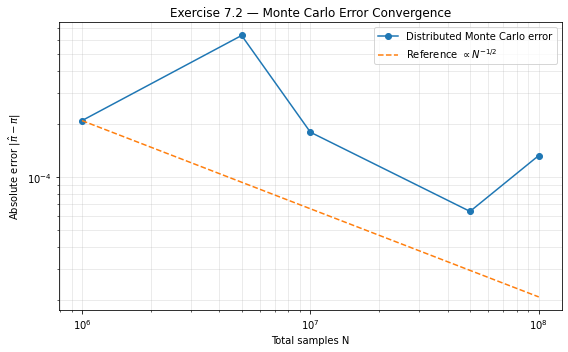

In [13]:
# Error convergence: expect O(N^-1/2)
N = dist_df["N"].to_numpy(dtype=float)
err = dist_df["error"].to_numpy(dtype=float)

ref_c = err[0] * np.sqrt(N[0])
ref_curve = ref_c / np.sqrt(N)

slope, intercept = np.polyfit(np.log10(N), np.log10(err), deg=1)
print(f"Observed log-log slope for error vs N: {slope:.3f} (expected -0.5)")

plt.figure(figsize=(8, 5))
plt.loglog(N, err, "o-", label="Distributed Monte Carlo error")
plt.loglog(N, ref_curve, "--", label=r"Reference $\propto N^{-1/2}$")
plt.xlabel("Total samples N")
plt.ylabel(r"Absolute error $|\hat{\pi} - \pi|$")
plt.title("Exercise 7.2 — Monte Carlo Error Convergence")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Exercise 7.3 (Optional) — 2D Particle Diffusion on the Cluster

In [14]:
SOURCES = np.array([[-15.0, 0.0], [15.0, 0.0], [0.0, 15.0]])
N_PER_SOURCE = 10_000
N_STEPS = 500
BATCH_SIZE = 2_500

N_BATCHES = N_PER_SOURCE // BATCH_SIZE
assert N_PER_SOURCE % BATCH_SIZE == 0


def walk_batch(source, seed, n_particles, n_steps):
    rng = np.random.default_rng(seed)
    steps = rng.normal(0.0, 1.0, size=(n_particles, n_steps, 2))
    return source + steps.sum(axis=1)


# Part A — Sequential
start = time.perf_counter()
chunks_a = []
for src_id, src in enumerate(SOURCES):
    chunks_a.append(
        walk_batch(src, seed=10_000 + src_id, n_particles=N_PER_SOURCE, n_steps=N_STEPS)
    )
pos_a = np.vstack(chunks_a)
time_a = time.perf_counter() - start

print(f"Part A time: {time_a:.3f}s, output shape: {pos_a.shape}")

Part A time: 0.754s, output shape: (30000, 2)


In [15]:
# Part B — dask.delayed (12 independent tasks)
walk_batch_delayed = delayed(walk_batch)

start = time.perf_counter()
tasks_b = []
for src_id, src in enumerate(SOURCES):
    for batch_id in range(N_BATCHES):
        seed = src_id * N_BATCHES + batch_id
        tasks_b.append(
            walk_batch_delayed(
                src,
                seed=seed,
                n_particles=BATCH_SIZE,
                n_steps=N_STEPS,
            )
        )

chunks_b = dask.compute(*tasks_b)
pos_b = np.vstack(chunks_b)
time_b = time.perf_counter() - start

print(f"Part B time: {time_b:.3f}s, output shape: {pos_b.shape}")

Part B time: 0.474s, output shape: (30000, 2)


In [16]:
# Part C — Futures + scatter
start = time.perf_counter()
scattered_sources = client.scatter([src for src in SOURCES], broadcast=True)

futures = []
for src_id, src_future in enumerate(scattered_sources):
    for batch_id in range(N_BATCHES):
        seed = src_id * N_BATCHES + batch_id
        futures.append(
            client.submit(
                walk_batch,
                src_future,
                seed,
                BATCH_SIZE,
                N_STEPS,
                pure=False,
            )
        )

chunks_c = [f.result() for f in as_completed(futures)]
pos_c = np.vstack(chunks_c)
time_c = time.perf_counter() - start

print(f"Part C time: {time_c:.3f}s, output shape: {pos_c.shape}")

Part C time: 0.514s, output shape: (30000, 2)


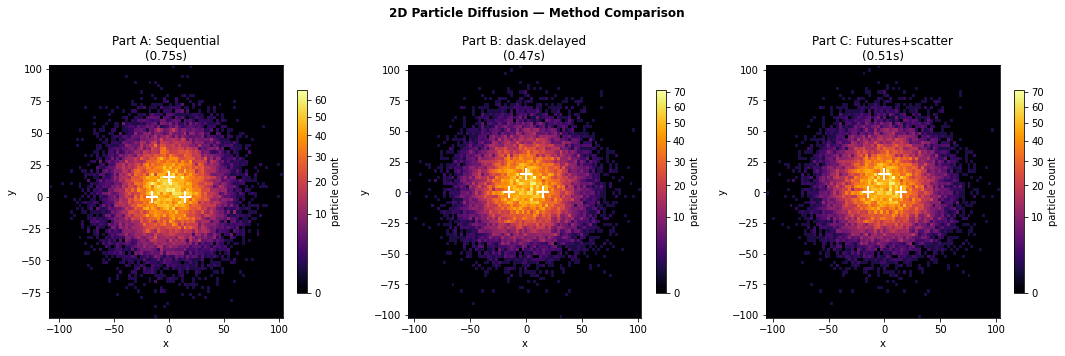

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("2D Particle Diffusion — Method Comparison", fontweight="bold")

titles = [
    f"Part A: Sequential\n({time_a:.2f}s)",
    f"Part B: dask.delayed\n({time_b:.2f}s)",
    f"Part C: Futures+scatter\n({time_c:.2f}s)",
]

for ax, pos, title in zip(axes, [pos_a, pos_b, pos_c], titles):
    h = ax.hist2d(
        pos[:, 0],
        pos[:, 1],
        bins=80,
        cmap="inferno",
        norm=mcolors.PowerNorm(gamma=0.5),
    )
    plt.colorbar(h[3], ax=ax, shrink=0.8, label="particle count")
    for src in SOURCES:
        ax.plot(src[0], src[1], "w+", ms=12, mew=2)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

plt.tight_layout()
plt.show()